In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML
import matplotlib.animation as animation
from scipy import stats

from neuralhydrology.datautils.utils import load_scaler
from neuralhydrology.modelzoo.cudalstm import CudaLSTM
from neuralhydrology.modelzoo.shm import SHM
from neuralhydrology.nh_run import start_run, eval_run
from neuralhydrology.utils.config import Config
from neuralhydrology.training.basetrainer import BaseTrainer
from neuralhydrology.modelzoo.cfe_modules import get_pet

This notebook implements the ensemble kalman filter for shm on one basin in Maine. States, parameters, or forcings are perturbed

# Set up LSTM and SHM data
Be sure to change the file name to a run on your device, if you don't have any saved runs, uncomment the start_run line and run it once.

In [9]:
# Make lstm instance
config_file = Path("1_basin.yml") # uses scaled data for proper lstm training
# RUN LINE BELOW if you dont have results from a run already
# start_run(config_file=config_file, gpu=-1)
lstm_config = Config(config_file)
run_dir = Path("runs/test_run_1203_222017") #CHANGE TO YOUR FILE NAME
cuda_lstm = CudaLSTM(cfg= lstm_config)
model_path = run_dir /'model_epoch030.pt'
model_weights = torch.load(str(model_path), map_location='cpu')
cuda_lstm.load_state_dict(model_weights) 

# get scaled data for lstm
seq_len = lstm_config.seq_length
# for whatever reason my linter thinks seq_len is not an int but it is ?
assert type(seq_len) == type(3)
trainer = BaseTrainer(cfg = lstm_config) # In line 108 of basetrainer.py, I changed shuffle = False in data loader initialization
trainer.initialize_training()
loader =  trainer.loader
itable = iter(loader)
for i in range(seq_len-1): # the data loader is padded with nans so skip those (this is not the most efficient but it works)
    _ = next(itable)
data_point = next(itable) # this data point is scaled and what the lstm uses

# evaluate the lstm to get predicted outflow
cuda_lstm.eval()
with torch.no_grad():
    z = cuda_lstm(data_point) # takes in the scaled data
z_plus_scaled = z['y_hat'][0, :, 0] # outputs scaled prediction
# Rescale back to og for plotting/comparison
scaler = load_scaler(run_dir)
center = float(scaler['xarray_feature_center']['QObs(mm/d)'].values)
scale = float(scaler['xarray_feature_scale']['QObs(mm/d)'].values)
z_plus= z_plus_scaled * scale + center 

#--------------------------------------------------------------------------------
# get raw data for shm
raw_data_config = Config(Path("raw_data.yml")) # This file has coustom normailation = None so data is not scaled
seq_len = raw_data_config.seq_length
trainer = BaseTrainer(cfg = raw_data_config)
trainer.initialize_training()
loader =  trainer.loader
itable = iter(loader)
for i in range(seq_len-1):
    _ = next(itable)
raw_data_point = next(itable)

# create shm model instance
shm_config_file = Path("shm_config.yml")
shm_config = Config(shm_config_file)
shm = SHM(cfg=shm_config)

# initialize shm parameters
shm_parameters = {
            "dd": torch.tensor(2.367, device="cpu", dtype=torch.float32),
            "f_thr": torch.tensor(41.688, device="cpu", dtype=torch.float32),
            "sumax": torch.tensor(41.964, device="cpu", dtype=torch.float32), 
            "beta": torch.tensor(1.023, device="cpu", dtype=torch.float32),
            "perc": torch.tensor(0.711, device="cpu", dtype=torch.float32), # percent to interflow vs baseflow
            "kf": torch.tensor(5.649, device="cpu", dtype=torch.float32), # unit is days to empty
            "ki": torch.tensor(4.963, device="cpu", dtype=torch.float32), # unit is days was 5
            "kb": torch.tensor(31.498, device="cpu", dtype=torch.float32), # unit is days was 15
            }

# Run shm with no assimilation for comparison
ss, sf, su, si, sb = shm.initialize_states(batch_size=1, device = 'cpu')
x = torch.tensor([ss,sf,su,si,sb])
shm_history = np.zeros((6,seq_len)) # to plot, = [ss, sf, su, si, sb, z_minus, ]
for j in range(seq_len):
    pet = get_pet.daily_pet_jensen2016(
                T_avg=(raw_data_point["x_d"]['tmax(C)'][0, j,0] + raw_data_point["x_d"]['tmin(C)'][0, j,0])/2,
                S_rad= raw_data_point["x_d"]['srad(W/m2)'][0,j,0],)
    forcing = np.stack([raw_data_point["x_d"]["prcp(mm/day)"][0,j,0], pet, raw_data_point["x_d"]["tmin(C)"][0,j,0], raw_data_point["x_d"]["tmax(C)"][0,j,0]])
    forcing_tensor = torch.tensor(forcing, dtype = torch.float32, device = "cpu").unsqueeze(dim = 0) # size [1,4] row vector, like u_k
    x[0], x[1], x[2], x[3], x[4], z_minus = shm.timestep_shm(x[0], x[1], x[2], x[3], x[4], shm_parameters, forcing_tensor, device = "cpu")
    shm_history[0:5,j] = torch.squeeze(x)
    shm_history[5,j] = z_minus

2026-05-30 09:59:09,345: Logging to /home/user/Coding/neuralhydrology-dcfe/examples/09-Data-Assimilation/runs/test_run_3005_095909/output.log initialized.
2026-05-30 09:59:09,347: ### Folder structure created at /home/user/Coding/neuralhydrology-dcfe/examples/09-Data-Assimilation/runs/test_run_3005_095909
2026-05-30 09:59:09,349: ### Run configurations for test_run
2026-05-30 09:59:09,350: experiment_name: test_run
2026-05-30 09:59:09,351: train_basin_file: 1_basin.txt
2026-05-30 09:59:09,353: validation_basin_file: 1_basin.txt
2026-05-30 09:59:09,354: test_basin_file: 1_basin.txt
2026-05-30 09:59:09,355: train_start_date: 1999-10-01 00:00:00
2026-05-30 09:59:09,358: train_end_date: 2008-09-30 00:00:00
2026-05-30 09:59:09,360: validation_start_date: 1980-10-01 00:00:00
2026-05-30 09:59:09,361: validation_end_date: 1989-09-30 00:00:00
2026-05-30 09:59:09,364: test_start_date: 1989-10-01 00:00:00
2026-05-30 09:59:09,366: test_end_date: 1999-09-30 00:00:00
2026-05-30 09:59:09,368: device:

2026-05-30 09:59:09,379: hidden_size: 20
2026-05-30 09:59:09,381: initial_forget_bias: 3
2026-05-30 09:59:09,383: output_dropout: 0.4
2026-05-30 09:59:09,386: optimizer: Adam
2026-05-30 09:59:09,388: loss: MSE
2026-05-30 09:59:09,389: learning_rate: {0: 0.01, 15: 0.005}
2026-05-30 09:59:09,392: batch_size: 1
2026-05-30 09:59:09,393: epochs: 20
2026-05-30 09:59:09,394: clip_gradient_norm: 1
2026-05-30 09:59:09,395: predict_last_n: 1
2026-05-30 09:59:09,397: seq_length: 730
2026-05-30 09:59:09,398: num_workers: 8
2026-05-30 09:59:09,399: log_interval: 5
2026-05-30 09:59:09,401: log_tensorboard: True
2026-05-30 09:59:09,404: log_n_figures: 1
2026-05-30 09:59:09,407: save_weights_every: 1
2026-05-30 09:59:09,409: allow_subsequent_nan_losses: 5
2026-05-30 09:59:09,411: dataset: camels_us
2026-05-30 09:59:09,413: data_dir: ../../data/CAMELS_US
2026-05-30 09:59:09,416: forcings: daymet
2026-05-30 09:59:09,418: dynamic_inputs: ['prcp(mm/day)', 'srad(W/m2)', 'tmax(C)', 'tmin(C)', 'vp(Pa)']
2026

### Optional Plots to make sure data look correct

In [ ]:
plt.figure(figsize= (20,8))
plt.plot(data_point["date"][0], data_point["y"][0,:,0], label = "outflow")
plt.plot(data_point["date"][0],data_point["x_d"]["prcp(mm/day)"][0,:,0], label = "precip")
plt.plot(data_point["date"][0],data_point["x_d"]["srad(W/m2)"][0,:,0], label = "srad")
plt.plot(data_point["date"][0],data_point["x_d"]["tmax(C)"][0,:,0], label = "tmax")
plt.plot(data_point["date"][0],data_point["x_d"]["tmax(C)"][0,:,0], label = "tmin")
plt.plot(data_point["date"][0],np.zeros(seq_len), linewidth = 3)
plt.title("Centered and Scaled Data")
plt.legend()

plt.figure(figsize= (20,8))
plt.plot(raw_data_point["date"][0],raw_data_point["y"][0,:,0], label = "outflow")
plt.plot(raw_data_point["date"][0],raw_data_point["x_d"]["prcp(mm/day)"][0,:,0], label = "precip")
plt.plot(raw_data_point["date"][0],raw_data_point["x_d"]["srad(W/m2)"][0,:,0], label = "srad")
plt.plot(raw_data_point["date"][0],raw_data_point["x_d"]["tmax(C)"][0,:,0], label = "tmax")
plt.plot(raw_data_point["date"][0],raw_data_point["x_d"]["tmax(C)"][0,:,0], label = "tmin")
plt.title("Raw Data")
plt.legend()

# SHM data asimilation

## Extended Kalman Fitler (no ensemble)

Following the equations in this paper [Towards an Interated Data Assimilation Framework](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2006WR005756)

That paper says that the following is the generic dynamic state-space formulation of a stochastic model (equations 20 and 21):

$x_{k+1} = M_{k+1}(x_k, \theta, u_{k+1}) + \eta_{k+1}$

$z_{k+1} = H_{k+1}(x_{k+1}, \theta) + \varepsilon_{k+1}$

Compared to the lecture notes from Xiu where the standard nonlinear hidden markov model is:

$X_{j+1} = m_j(X_j) + W_j$

$Y_j = h_j(X_j) + \epsilon_j$

The difference is wether the observation operator $H_{k+1}$ or $h_j$ depends on the state $X$ or $x$ at the same timestep as the state transition model or the timestep after. In the context of SHM that means we can either use a constant version of $H$ which is consistent with the first set of equations

$$ \bm{H} = \begin{bmatrix}
0 & \frac{1}{k_f -1} & 0 & \frac{1}{k_i -1} & \frac{1}{k_b -1} 
\end{bmatrix}$$

or the last row of the jacobian (outflow) of shm with respect to the states as 

$$ \bm{H} = \begin{bmatrix}
\frac{\partial z}{\partial ss}  & \frac{\partial z}{\partial sf} & \frac{\partial z}{\partial su} & \frac{\partial z}{\partial si} & \frac{\partial z}{\partial sb} \end{bmatrix}$$



In [ ]:
P_p = 10.0* torch.eye(5) # initial error covariance matrix
# I used _p to represent + and _m for -
Q = 90.0*torch.eye(5) # model error covariance
R = 10.0 #observation error variance
#the larger Q is compared to R the more the states are assimilated to match lstm
# H = torch.tensor([[0.0, 1/(shm_parameters["kf"]-1),0.0,1/(shm_parameters["ki"]-1),1/(shm_parameters["kb"]-1)]])
ss, sf, su, si, sb = shm.initialize_states(batch_size = 1, device = "cpu")
x = torch.tensor([[ss],[sf],[su],[si],[sb]])
history = np.zeros((6,seq_len)) # for plotting [ss+, sf+, su+, si+, sb+, z_plus]
H_history = np.zeros((seq_len, 5)) # store each H (1x5) across seq_len
history[0:5,0] = torch.squeeze(x)
history[5,0] = z_plus[0]
for j in range(1,seq_len): #each day
    # set up forcing input
    pet = get_pet.daily_pet_jensen2016(
                T_avg=(raw_data_point["x_d"]['tmax(C)'][0, j,0] + raw_data_point["x_d"]['tmin(C)'][0, j,0])/2,
                S_rad= raw_data_point["x_d"]['srad(W/m2)'][0,j,0],)
    forcing = np.stack([raw_data_point["x_d"]["prcp(mm/day)"][0,j,0], pet, raw_data_point["x_d"]["tmin(C)"][0,j,0], raw_data_point["x_d"]["tmax(C)"][0,j,0]])
    forcing_tensor = torch.tensor(forcing, dtype = torch.float32, device = "cpu").unsqueeze(dim = 0) # size [1,4] row vector, like u_k
    # get jacobian 
    shm_tensor = shm.timestep_shm_tensor_fxn(timestep_params=shm_parameters, x_conceptual_timestep=forcing_tensor, device = "cpu")
    J = torch.autograd.functional.jacobian(shm_tensor, x.squeeze())
    M = J[0:5]
    # could use H defined outside loop instead
    H = (J[5]).unsqueeze(dim = 0) # 1x5
    H_history[j] = H.detach().numpy() # save H at this timestep
    x[0], x[1], x[2], x[3], x[4], z_m = shm.timestep_shm(x[0], x[1], x[2], x[3], x[4], shm_parameters, forcing_tensor, device = "cpu") # eq (22) and (27)
    d = z_plus[j] - z_m # eq (26) z_plus[j] is from lstm 
    P_m = M @ P_p @ M.T + Q #eq (23)
    K = (P_m @ H.T) *(1/(H @ P_m @ H.T + R)) #eq (28) 
    P_p = P_m - (K @ H) * P_m # eq (25)
    x = x + K*d # eq (24)
    x = torch.clamp(x,0) # no negative states
    history[0:5,j] = torch.squeeze(x)
    history[5,j] = z_m

In [ ]:
# OPTIONAL plot
# original shm output
plt.figure(figsize=(20, 8))
plt.plot(shm_history[0,:], label='snow storage', linewidth=2.0, color='C0')
plt.plot(shm_history[1,:], label='fast-flow', linewidth=2.0, color='C1')
plt.plot(shm_history[2,:], label='unsat-zone', linewidth=2.0, color='C2')
plt.plot(shm_history[3,:], label='interflow', linewidth=2.0, color='C3')
plt.plot(shm_history[4,:], label='baseflow', linewidth=2.0, color='C4')
# assimilated states with dashed lines in same colors
plt.plot(history[0,:], label='snow storage (DA)', linewidth=2.0, color='C0', linestyle='--')
plt.plot(history[1,:], label='fast-flow (DA)', linewidth=2.0, color='C1', linestyle='--')
plt.plot(history[2,:], label='unsat-zone (DA)', linewidth=2.0, color='C2', linestyle='--')
plt.plot(history[3,:], label='interflow (DA)', linewidth=2.0, color='C3', linestyle='--')
plt.plot(history[4,:], label='baseflow (DA)', linewidth=2.0, color='C4', linestyle='--')
plt.title("States")
plt.legend()

plt.figure(figsize= (20,8))
plt.plot(z_plus, label = "z_plus (LSTM)")
plt.plot(shm_history[5,:], label = "shm outflow no DA")
plt.plot(history[5,:], label = "shm outflow with DA")
plt.plot(raw_data_point["y"][0,:,0], label = "Observed outflow")
plt.legend()
plt.show()

## Ensemble Kalman Filter
These are implemented based on ExKF_ExKF notes
### Perturbed forcings

In [ ]:
N = 100 # number of ensemble members
ss, sf, su, si, sb = shm.initialize_states(batch_size = 1, device = "cpu")
x = torch.tensor([ss,sf,su,si,sb])
Xpts = x.repeat(N,1) # Nx5
history = np.zeros((7,seq_len))
history[0:5,0] = torch.squeeze(x)
history[5,0] = z_plus[0]
for j in range(seq_len): #each day
    sigma_temp = 1 # can change, does weird things when to big, like 10
    temp_noise = torch.randn(size = (N,))
    # add same noise to min and max becase shm uses average
    tmax = raw_data_point["x_d"]['tmax(C)'][0,j,0] + temp_noise*sigma_temp # shape N
    tmin = raw_data_point["x_d"]['tmin(C)'][0,j,0] + temp_noise*sigma_temp # shape N
    sigma_srad = 30
    srad = raw_data_point["x_d"]["srad(W/m2)"][0,j,0] + torch.randn(size = (N,))*sigma_srad
    pet = get_pet.daily_pet_jensen2016(
                T_avg=(tmax + tmin)/2,
                S_rad= srad,)
    forcing = np.stack([raw_data_point["x_d"]["prcp(mm/day)"][0,j,0].expand(N), pet, tmin, tmax])
    forcing_tensor = torch.tensor(forcing, dtype = torch.float32, device = "cpu").unsqueeze(dim = 0) # size 1x4x100
    ss, sf, su, si, sb, Zpts = shm.timestep_shm(Xpts[:,0], Xpts[:,1], Xpts[:,2], Xpts[:,3], Xpts[:,4], shm_parameters, forcing_tensor, device = "cpu")
    Xpts = torch.stack([ss.squeeze(), sf.squeeze(), su.squeeze(), si.squeeze(), sb.squeeze()], dim=1)
    x = Xpts.mean(dim=0) #eq (21)
    z = Zpts.mean()
    A = (1/np.sqrt(N-1) * (Xpts - x)).T #eq (23) scaled state ensemble perturbation matrix 5,N
    V = 1/np.sqrt(N-1) * (Zpts - z) #eq (29) scaled output ensemble perturbation matrix 1,N 
    K = A @ V.T * 1/(V @ V.T + R) #eq (40) 5,1 = 5,N @ N,1 
    Xpts = Xpts + (z_plus[j] - Zpts).T @ K.T #eq (40) N,5 = N,5 + N,1 @ 1,5 
    xplus = Xpts.mean(dim=0)
    x = torch.clamp(xplus, 0)
    # should we also clamp negative ensemble members?
    history[5,j] = z 
    history[0:5, j] = x[0:5]
    history[6,j] = torch.std(Zpts)

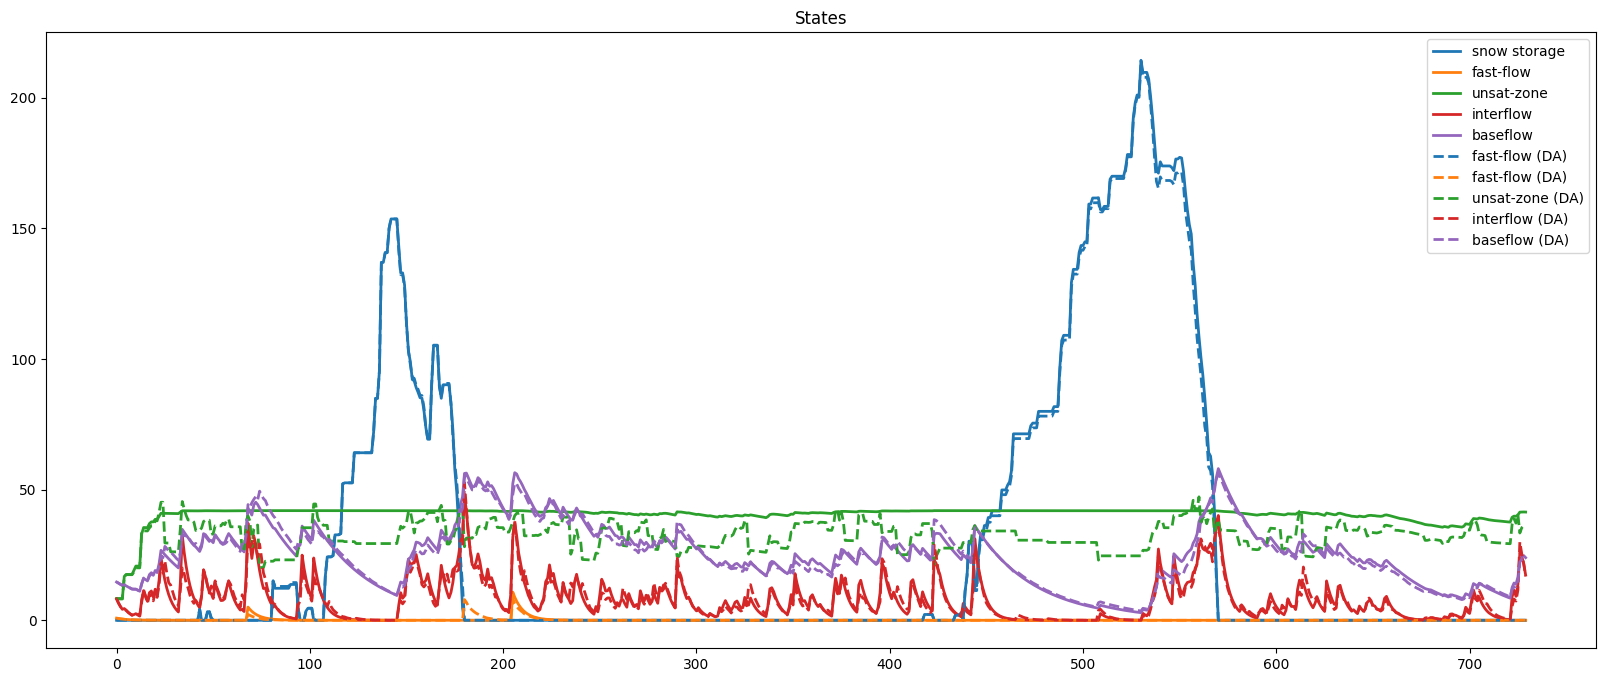

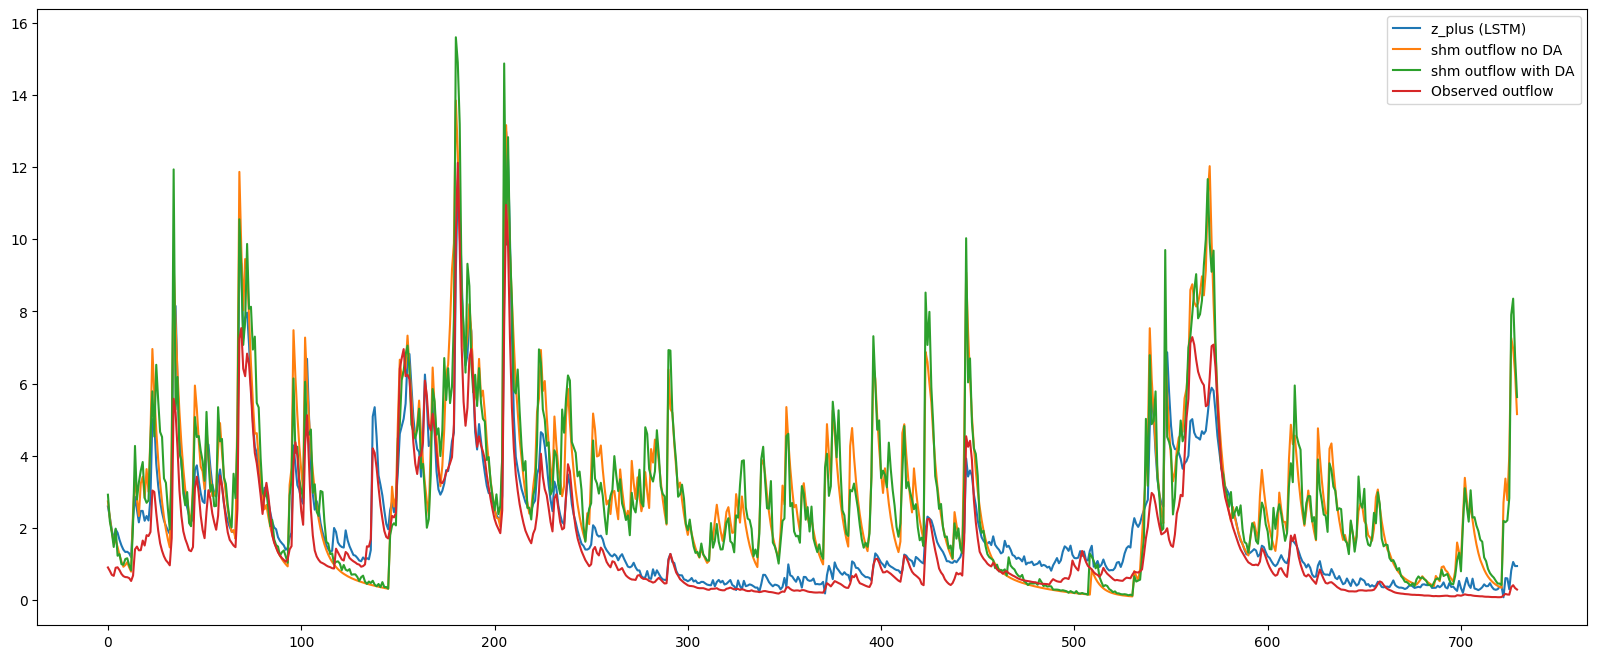

In [21]:
# OPTIONAL plot
# original shm output
plt.figure(figsize=(20, 8))
plt.plot(shm_history[0,:], label='snow storage', linewidth=2.0, color='C0')
plt.plot(shm_history[1,:], label='fast-flow', linewidth=2.0, color='C1')
plt.plot(shm_history[2,:], label='unsat-zone', linewidth=2.0, color='C2')
plt.plot(shm_history[3,:], label='interflow', linewidth=2.0, color='C3')
plt.plot(shm_history[4,:], label='baseflow', linewidth=2.0, color='C4')
# assimilated states with dashed lines in same colors
plt.plot(history[0,:], label='fast-flow (DA)', linewidth=2.0, color='C0', linestyle='--')
plt.plot(history[1,:], label='fast-flow (DA)', linewidth=2.0, color='C1', linestyle='--')
plt.plot(history[2,:], label='unsat-zone (DA)', linewidth=2.0, color='C2', linestyle='--')
plt.plot(history[3,:], label='interflow (DA)', linewidth=2.0, color='C3', linestyle='--')
plt.plot(history[4,:], label='baseflow (DA)', linewidth=2.0, color='C4', linestyle='--')
plt.title("States")
plt.legend()

plt.figure(figsize= (20,8))
plt.plot(z_plus, label = "z_plus (LSTM)")
plt.plot(shm_history[5,:], label = "shm outflow no DA")
plt.plot(history[5,:], label = "shm outflow with DA")
plt.plot(raw_data_point["y"][0,:,0], label = "Observed outflow")
plt.legend()
plt.show()

### Perturbed states
SHM will return nans but not throw an error if you pass in negative states. Some of the staes are zero at certain time points, like snow and fast flow.
This doesn't work completely as intended becasue the states have a hard cut off at 0. The ensemble looses spread when they are all 0, or all at sumax.

In [17]:
N = 100 # number of ensemble members
R = 1
x = torch.tensor([5.0,5.0,40.0,10.0,20.0]) 
mvn = torch.distributions.MultivariateNormal(x, torch.diag(torch.tensor([1.0, 1.0, 10.0, 1.0, 10.0])))
Xpts = mvn.sample((N,)) # Nx5
# Shm will return nan but still keep working if you pass in negative states
history = np.zeros((7,seq_len))
history[0:5,0] = torch.squeeze(x)
history[5,0] = z_plus[0]
for j in range(seq_len): #each day
    pet = get_pet.daily_pet_jensen2016(
                T_avg=(raw_data_point["x_d"]['tmax(C)'][0, j,0] + raw_data_point["x_d"]['tmin(C)'][0, j,0])/2,
                S_rad= raw_data_point["x_d"]["srad(W/m2)"][0,j,0],)
    forcing = np.stack([raw_data_point["x_d"]["prcp(mm/day)"][0,j,0].expand(N), pet.expand(N), raw_data_point["x_d"]['tmin(C)'][0, j,0].expand(N), raw_data_point["x_d"]['tmax(C)'][0, j,0].expand(N)])
    forcing_tensor = torch.tensor(forcing, dtype = torch.float32, device = "cpu").unsqueeze(dim = 0) # size 1x4x100 identical for each ensemble member
    s, f, u, i, b, Zpts = shm.timestep_shm(Xpts[:,0], Xpts[:,1], Xpts[:,2], Xpts[:,3], Xpts[:,4], shm_parameters, forcing_tensor, device = "cpu")
    Xpts = torch.stack([s.squeeze(), f.squeeze(), u.squeeze(), i.squeeze(), b.squeeze()], dim=1)
    x = Xpts.mean(dim=0) #eq (21)
    A = (1/np.sqrt(N-1) * (Xpts - x).T) #eq (23) scaled state ensemble perturbation matrix 5,N
    V = 1/np.sqrt(N-1) * (Zpts - z_plus[j]) #eq (29) scaled output ensemble perturbation matrix 1,N 
    K = A @ V.T * 1/(V @ V.T + R) #eq (40) 5,1 = 5,N @ N,1 
    Xpts = Xpts + (z_plus[j] - Zpts).T @ K.T #eq (40) N,5 = N,5 + N,1 @ 1,5  
    print("Zs", z_plus[j] - Zpts)
    print("K", K)
    xplus = Xpts.mean(dim=0)
    x = torch.clamp(xplus, 0)
    z = Zpts.mean()
    history[5,j] = z 
    history[0:5, j] = x[0:5]
    history[6,j] = torch.std(Zpts)
print(Xpts[:,0], Xpts[:,1], Xpts[:,2], Xpts[:,3], Xpts[:,4])

Zs tensor([[-2.4319, -2.4812, -2.2515, -3.3994, -2.0416, -2.2594, -2.2471, -2.9912,
         -2.1547, -2.1063, -2.1646, -2.7328, -2.0016, -2.1609, -1.5428, -3.1550,
         -2.5960, -2.5919, -2.7881, -2.1541, -2.5111, -2.5399, -2.9510, -2.2511,
         -2.3509, -2.0150, -2.2239, -2.0294, -2.7180, -2.5488, -2.5731, -2.4799,
         -2.1507, -2.6050, -1.8999, -1.8920, -1.8670, -2.1061, -1.7688, -2.3099,
         -2.2644, -2.4683, -1.9198, -2.3678, -2.3950, -2.0719, -2.0425, -2.5930,
         -3.1977, -2.1275, -1.9216, -2.0912, -1.6190, -2.8929, -2.0895, -2.2314,
         -2.5584, -2.1684, -1.9672, -2.3087, -2.1858, -2.2236, -2.5298, -2.3987,
         -1.6835, -2.4828, -2.1503, -2.4161, -2.0746, -2.7935, -2.2497, -1.9287,
         -2.1825, -1.9012, -3.3489, -2.6969, -1.8440, -2.1986, -1.9013, -2.2163,
         -4.0518, -1.9540, -2.3087, -2.6448, -2.2347, -1.0686, -1.9162, -2.2197,
         -2.8982, -2.2930, -3.0158, -2.3935, -2.1330, -1.6063, -1.8933, -2.1565,
         -2.7965, -2.1321

### Perturbed parameters
The unsaturated zone behaves wierd here because it almost always at its max, and the max is the parameter sumax.

In [20]:
N = 100 # number of ensemble members
x = torch.tensor([ss,sf,su,si,sb])
Xpts = x.repeat(N,1) # Nx5
history = np.zeros((7,seq_len))
history[0:5,0] = torch.squeeze(x)
history[5,0] = z_plus[0]
shm_parameters = {
    "dd": torch.tensor(2.367, device="cpu", dtype=torch.float32),
    "f_thr": torch.tensor(41.688, device="cpu", dtype=torch.float32),
    "sumax": torch.tensor(41.964, device="cpu", dtype=torch.float32),             
    "beta": torch.tensor(1.023, device="cpu", dtype=torch.float32),
    "perc": torch.tensor(0.711, device="cpu", dtype=torch.float32), # percent to interflow vs baseflow
    "kf": torch.tensor(5.649, device="cpu", dtype=torch.float32), # unit is days to empty
    "ki": torch.tensor(4.963, device="cpu", dtype=torch.float32), # unit is days was 5
    "kb": torch.tensor(31.498, device="cpu", dtype=torch.float32), # unit is days was 15
        }
for j in range(seq_len): #each day
    pet = get_pet.daily_pet_jensen2016(
                T_avg=(raw_data_point["x_d"]['tmax(C)'][0, j,0] + raw_data_point["x_d"]['tmin(C)'][0, j,0])/2,
                S_rad= raw_data_point["x_d"]["srad(W/m2)"][0,j,0])
    forcing = np.stack([raw_data_point["x_d"]["prcp(mm/day)"][0,j,0].expand(N), pet.expand(N), raw_data_point["x_d"]['tmin(C)'][0, j,0].expand(N), raw_data_point["x_d"]['tmax(C)'][0, j,0].expand(N)])
    forcing_tensor = torch.tensor(forcing, dtype = torch.float32, device = "cpu").unsqueeze(dim = 0) # size 1x4x100
    dd = shm_parameters["dd"] + torch.randn(1)*0.5 # could tune these standard deviations
    f_thr  = shm_parameters["f_thr"] + torch.randn(1)*7.0
    sumax = shm_parameters["sumax"] + torch.randn(1)*7.0
    beta = shm_parameters["beta"] + torch.randn(1)*0.2
    perc = shm_parameters["perc"] + torch.randn(1)*0.05
    kf = shm_parameters["kf"] + torch.randn(1)*0.8
    ki = shm_parameters["ki"] + torch.randn(1)*0.7
    kb = shm_parameters["kb"] + torch.randn(1)*3.0
    perturbed_params = {
    "dd": dd,
    "f_thr": f_thr,
    "sumax": sumax,             
    "beta": beta,
    "perc": perc,
    "kf": kf,
    "ki": ki,
    "kb": kb,
        }
    s, f, u, i, b, Zpts = shm.timestep_shm(Xpts[:,0], Xpts[:,1], Xpts[:,2], Xpts[:,3], Xpts[:,4], perturbed_params, forcing_tensor, device = "cpu")
    Xpts = torch.stack([s.squeeze(), f.squeeze(), u.squeeze(), i.squeeze(), b.squeeze()], dim=1)
    x = Xpts.mean(dim=0) #eq (21)
    A = (1/np.sqrt(N-1) * (Xpts - x).T) #eq (23) scaled state ensemble perturbation matrix 5,N
    V = 1/np.sqrt(N-1) * (Zpts - z_plus[j]) #eq (29) scaled output ensemble perturbation matrix 1,N 
    K = A @ V.T * 1/(V @ V.T + R) #eq (40) 5,1 = 5,N @ N,1 
    Xpts = Xpts + (z_plus[j] - Zpts).T @ K.T #eq (40) N,5 = N,5 + N,1 @ 1,5  
    xplus = Xpts.mean(dim=0)
    x = torch.clamp(xplus, 0)
    z = Zpts.mean()
    history[5,j] = z 
    history[0:5, j] = x[0:5]
    history[6,j] = torch.std(Zpts)